24BAD061 - KRITHIKA K
PART A - DATASET PREPARATION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.layers import TextVectorization
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
!pip install -q importlib_resources

(train_data, test_data), info = tfds.load(
    "imdb_reviews",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print("Training samples:", info.splits["train"].num_examples)
print("Testing samples:", info.splits["test"].num_examples)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.GIWR8U_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.GIWR8U_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.GIWR8U_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Training samples: 25000
Testing samples: 25000


In [4]:
train_reviews = []
train_labels = []

for review, label in tfds.as_numpy(train_data):
    train_reviews.append(review.decode("utf-8"))
    train_labels.append(label)

test_reviews = []
test_labels = []

for review, label in tfds.as_numpy(test_data):
    test_reviews.append(review.decode("utf-8"))
    test_labels.append(label)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df = pd.DataFrame({
    "Review": train_reviews,
    "Sentiment": train_labels
})

df["Sentiment"] = df["Sentiment"].map({
    0: "Negative",
    1: "Positive"
})

print(df.head())
print("\nDataset shape:", df.shape)
print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

                                              Review Sentiment
0  This was an absolutely terrible movie. Don't b...  Negative
1  I have been known to fall asleep during films,...  Negative
2  Mann photographs the Alberta Rocky Mountains i...  Negative
3  This is the kind of film for a snowy Sunday af...  Positive
4  As others have mentioned, all the women that g...  Positive

Dataset shape: (25000, 2)

Sentiment distribution:
Sentiment
Negative    12500
Positive    12500
Name: count, dtype: int64


In [6]:
print("Sample Review:")
print(train_reviews[0])

print("\nSentiment Label:", train_labels[0])

if train_labels[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

Sample Review:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.

Sentiment Label: 0
Sentiment: Negative


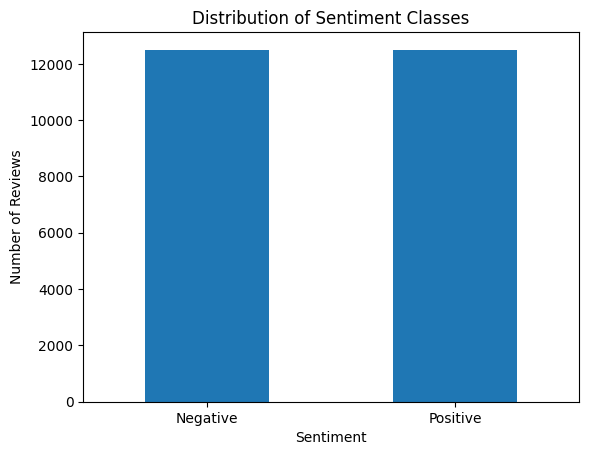

In [7]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    xlabel="Sentiment",
    ylabel="Number of Reviews",
    title="Distribution of Sentiment Classes",
    rot=0
)

plt.show()

In [8]:
max_words = 10000
max_length = 200

vectorizer = TextVectorization(
    max_tokens=max_words,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_length
)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_reviews).batch(256)
)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))
print("\nSample vocabulary:")
print(vectorizer.get_vocabulary()[:20])

Vocabulary size: 10000

Sample vocabulary:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('br'), np.str_('was'), np.str_('as'), np.str_('for'), np.str_('with'), np.str_('movie'), np.str_('but')]


In [9]:
X_train_all = vectorizer(
    tf.constant(train_reviews)
).numpy()

X_test = vectorizer(
    tf.constant(test_reviews)
).numpy()

y_train_all = train_labels
y_test = test_labels

print("Training sequence shape:", X_train_all.shape)
print("Testing sequence shape:", X_test.shape)

print("\nFirst review as numerical sequence:")
print(X_train_all[0])

Training sequence shape: (25000, 200)
Testing sequence shape: (25000, 200)

First review as numerical sequence:
[  11   14   34  412  384   18   90   28    1    8   33 1322 3560   42
  487    1  191   24   85  152   19   11  217  316   28   65  240  214
    8  489   54   65   85  112   96   22 5596   11   93  642  743   11
   18    7   34  394 9522  170 2464  408    2   88 1216  137   66  144
   51    2    1 7558   66  245   65 2870   16    1 2860    1    1 1426
 5050    3   40    1 1579   17 3560   14  158   19    4 1216  891 8040
    8    4   18   12   14 4059    5   99  146 1241   10  237  704   12
   48   24   93   39   11 7339  152   39 1322    1   50  398   10   96
 1155  851  141    9    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0 

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all
)

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)
print("Testing data:", X_test.shape, y_test.shape)

Training data: (20000, 200) (20000,)
Validation data: (5000, 200) (5000,)
Testing data: (25000, 200) (25000,)


In [11]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nSequence length:", X_train.shape[1])
print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

print("\nData preparation completed successfully!")

Training samples: 20000
Validation samples: 5000
Testing samples: 25000

Sequence length: 200
Number of classes: 2
Classes: [0 1]

Data preparation completed successfully!


PART B: IMPLEMENTING THE LSTM MODEL

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

print("LSTM model created successfully!")

LSTM model created successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [14]:
model.build(input_shape=(None, max_length))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.summary()

print("\nTotal parameters:", model.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 673089


PART C: MODEL TRAINING AND PERFORMANCE EVALUATION

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 262ms/step - accuracy: 0.5500 - loss: 0.6830 - val_accuracy: 0.5920 - val_loss: 0.6696
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.6179 - loss: 0.6533 - val_accuracy: 0.6540 - val_loss: 0.6345
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.6501 - loss: 0.6254 - val_accuracy: 0.6356 - val_loss: 0.6492
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 198ms/step - accuracy: 0.6295 - loss: 0.6333 - val_accuracy: 0.5968 - val_loss: 0.6341
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 134ms/step - accuracy: 0.7229 - loss: 0.5247 - val_accuracy: 0.7758 - val_loss: 0.5198


In [17]:
results = pd.DataFrame({
    "Epoch": range(1, len(history.history["accuracy"]) + 1),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

print(results.round(4).to_string(index=False))

 Epoch  Training Accuracy  Validation Accuracy  Training Loss  Validation Loss
     1             0.5500               0.5920         0.6830           0.6696
     2             0.6179               0.6540         0.6533           0.6345
     3             0.6501               0.6356         0.6254           0.6492
     4             0.6295               0.5968         0.6333           0.6341
     5             0.7229               0.7758         0.5247           0.5198


In [18]:
test_loss, test_accuracy = model.evaluate(
    X_test, y_test, verbose=1
)

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Loss:", round(test_loss, 4))

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.7679 - loss: 0.5387
Test Accuracy: 0.7679
Test Loss: 0.5387


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_prob = model.predict(X_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.7679
Precision: 0.8065
Recall   : 0.705
F1-score : 0.7523


Confusion Matrix:
 [[10386  2114]
 [ 3688  8812]]


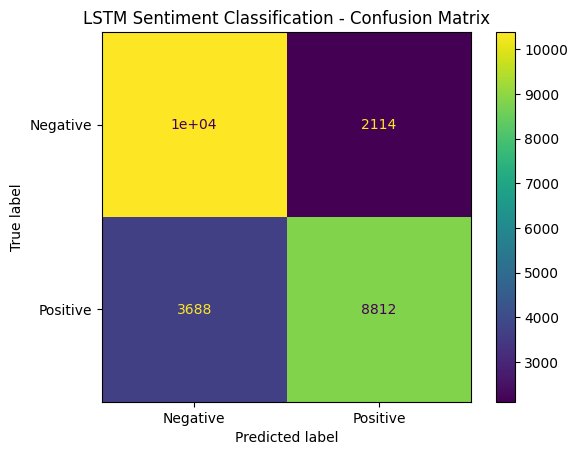

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("LSTM Sentiment Classification - Confusion Matrix")
plt.show()

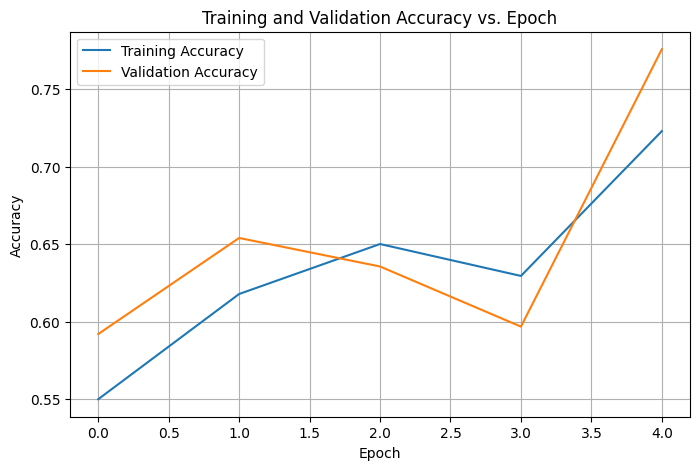

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

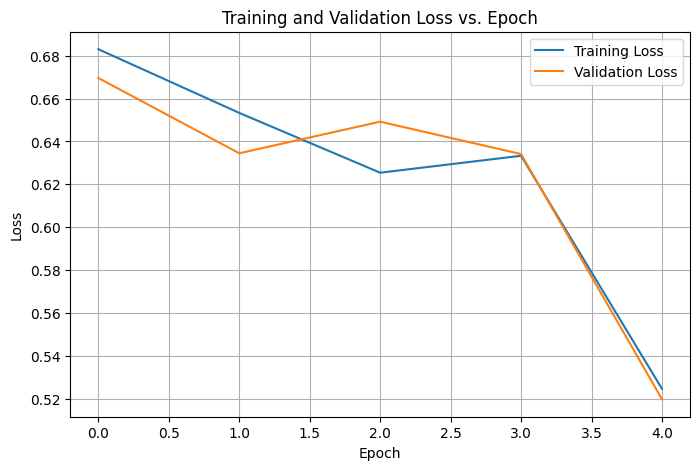

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

              precision    recall  f1-score   support

    Negative       0.74      0.83      0.78     12500
    Positive       0.81      0.70      0.75     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000



PART D: Sentiment Prediction and Deep Learning Experiment Management

In [24]:
reviews = [
    "This movie was fantastic and I loved every moment.",
    "The film was boring and a complete waste of time.",
    "The acting was excellent and the story was wonderful.",
    "I did not enjoy this movie at all.",
    "The movie was okay, but nothing special.",
    "Amazing direction and brilliant performances."
]

expected_sentiments = [
    "Positive",
    "Negative",
    "Positive",
    "Negative",
    "Neutral",
    "Positive"
]

print("Number of reviews:", len(reviews))

Number of reviews: 6


In [25]:
X_new = vectorizer(
    tf.constant(reviews)
).numpy()

print("Tokenized and padded sequences:")
print(X_new)

print("\nInput shape:", X_new.shape)

Tokenized and padded sequences:
[[ 11  18  14 ...   0   0   0]
 [  2  20  14 ...   0   0   0]
 [  2 112  14 ...   0   0   0]
 [ 10 117  22 ...   0   0   0]
 [  2  18  14 ...   0   0   0]
 [473 463   3 ...   0   0   0]]

Input shape: (6, 200)


In [26]:
probabilities = model.predict(X_new, verbose=0).flatten()

predicted_sentiments = [
    "Positive" if p >= 0.5 else "Negative"
    for p in probabilities
]

print("Sentiment predictions completed!")

Sentiment predictions completed!


In [27]:
results = pd.DataFrame({
    "Review": reviews,
    "Expected Sentiment": expected_sentiments,
    "Predicted Sentiment": predicted_sentiments,
    "Positive Probability": probabilities.round(4)
})

print(results.to_string(index=False))

                                               Review Expected Sentiment Predicted Sentiment  Positive Probability
   This movie was fantastic and I loved every moment.           Positive            Positive                0.7460
    The film was boring and a complete waste of time.           Negative            Negative                0.1715
The acting was excellent and the story was wonderful.           Positive            Positive                0.7460
                   I did not enjoy this movie at all.           Negative            Positive                0.7460
             The movie was okay, but nothing special.            Neutral            Negative                0.1715
        Amazing direction and brilliant performances.           Positive            Positive                0.7460


In [28]:
binary_indices = [
    i for i, sentiment in enumerate(expected_sentiments)
    if sentiment in ["Positive", "Negative"]
]

correct = sum(
    predicted_sentiments[i] == expected_sentiments[i]
    for i in binary_indices
)

total = len(binary_indices)
prediction_accuracy = correct / total * 100

print("Correct predictions:", correct, "/", total)
print("Accuracy on sample reviews:", round(prediction_accuracy, 2), "%")

Correct predictions: 4 / 5
Accuracy on sample reviews: 80.0 %


In [29]:
print("OBSERVATIONS")
print("-" * 40)

for i in range(len(reviews)):
    print("\nReview:", reviews[i])
    print("Expected:", expected_sentiments[i])
    print("Predicted:", predicted_sentiments[i])
    print("Positive probability:", round(probabilities[i], 4))

    if expected_sentiments[i] == "Neutral":
        print("Observation: Neutral sentiment is not supported.")
    elif predicted_sentiments[i] == expected_sentiments[i]:
        print("Observation: Prediction matches expected sentiment.")
    else:
        print("Observation: Prediction differs from expected sentiment.")

OBSERVATIONS
----------------------------------------

Review: This movie was fantastic and I loved every moment.
Expected: Positive
Predicted: Positive
Positive probability: 0.746
Observation: Prediction matches expected sentiment.

Review: The film was boring and a complete waste of time.
Expected: Negative
Predicted: Negative
Positive probability: 0.1715
Observation: Prediction matches expected sentiment.

Review: The acting was excellent and the story was wonderful.
Expected: Positive
Predicted: Positive
Positive probability: 0.746
Observation: Prediction matches expected sentiment.

Review: I did not enjoy this movie at all.
Expected: Negative
Predicted: Positive
Positive probability: 0.746
Observation: Prediction differs from expected sentiment.

Review: The movie was okay, but nothing special.
Expected: Neutral
Predicted: Negative
Positive probability: 0.1715
Observation: Neutral sentiment is not supported.

Review: Amazing direction and brilliant performances.
Expected: Positiv